## Inputs and Execution Setting

This section reports the execution setting used by `huba_goccva_pipeline.py`. The script takes a goal model as input, constructs a process model for alignment-based conformance checking, simulates an event log, derives an activity-to-task mapping, computes alignments, and then derives goal-oriented alignments and trace classifications.

### Goal model input

The goal model is provided as a piStar-style JSON structure with four main components:

- `actors`
- `links`
- `dependencies`
- `display` metadata

From this structure, `huba_goccva_pipeline.py` reconstructs the following domain objects:

- **actors**: organizational entities that own intentional elements
- **intentional elements**:
  - goals
  - tasks
  - qualities
- **internal links**:
  - AND-refinement
  - OR-refinement
  - contribution links labeled `make` or `break`
- **dependencies**:
  - depender
  - dependum
  - dependee

### Goal model used in the script

The uploaded goal model contains the following actors:

- **System**
- **Hospital Officer**
- **Auditor**
- **Blind Patient**

It contains the following main intentional elements.

#### System
- `Verify identity` (Task)
- `Identity verified` (Task)
- `Identity denied` (Task)

#### Hospital Officer
- `Format Data Regular Needs` (Task)
- `Format Data Special Needs` (Task)
- `Provide Records` (Task)
- `Identity verified` (Goal)
- `Data access provided` (Goal)
- `data easily accesible` (Quality)

#### Auditor
- `confidentiality` (Quality)

#### Blind Patient
- actor present in the dependency structure

### Internal link structure

The model contains the following internal relations:

#### Refinement links
`Data access provided` is AND-refined by:
- `Identity verified`
- `Format Data Special Needs`
- `Provide Records`

#### Contribution links
- `Format Data Special Needs` `make` `data easily accesible`
- `Format Data Regular Needs` `break` `data easily accesible`

### Dependency structure

The model contains three cross-actor dependencies:

1. **System → Hospital Officer**
   - dependum: `Identity verified`

2. **Auditor → Hospital Officer**
   - dependum: `appropriate measures`

3. **Blind Patient → Hospital Officer**
   - dependum: `data easily accesible`

In the implementation, these dependencies are used by the propagation step to transfer marking values from dependee-side elements to the dependum and, when defined, also to the depender-side element.

---

## Selected targets

`huba_goccva_pipeline.py` selects targets from the parsed goal model. The script first tries to identify the following names:

- `Data access provided`
- `data easily accesible`

If both are present, they are used as the target set.  
If they are not present, the script falls back to one goal and one quality.

For the current input, the target set is:

- **Goal target**: `Data access provided`
- **Quality target**: `data easily accesible`

These targets determine:
- the target-relevant leaf task sets
- the move labels in the goal-oriented alignment
- the final classification of each trace

---

## Process model used for alignments

The process model is not loaded from an external BPMN or PNML source.  
`huba_goccva_pipeline.py` constructs a Petri net in code so that the control-flow matches the healthcare running example.

### Activities in the Petri net
- `Verify identity`
- `Identity denied`
- `Identity verified`
- `Format Data Regular Needs`
- `Format Data Special Needs`
- `Provide Records`

### Control-flow structure

The process starts with identity verification.  
After verification, two outcomes are possible:

- identity is denied, and the case stops
- identity is verified, and the case continues

If identity is verified, the officer can prepare the output in one of two ways:

- regular-needs formatting
- special-needs formatting

The case ends with record provision.

### Process model rendering

```text
Start
  |
  v
Verify identity
  |
  +------------------------------+
  |                              |
  v                              v
Identity denied            Identity verified
  |                              |
  |                       +------+------+
  |                       |             |
  |                       v             v
  |            Format Data Regular   Format Data Special
  |                  Needs                Needs
  |                       \             /
  |                        \           /
  |                         v         v
  |                     Provide Records
  |                              |
  +---------------> End <--------+

In [1]:
import json
import pandas as pd
from IPython.display import display, Markdown

GOAL_MODEL_PATH = "content/gm.txt"
DETAILS_PATH = "content/goccva_details.json"
SUMMARY_PATH = "content/goccva_summary.csv"
MAPPING_PATH = "content/goccva_mapping.csv"
TARGETS_PATH = "content/goccva_targets.csv"

with open(GOAL_MODEL_PATH, "r", encoding="utf-8") as f:
    gm_raw = json.load(f)

with open(DETAILS_PATH, "r", encoding="utf-8") as f:
    details = json.load(f)

summary = pd.read_csv(SUMMARY_PATH)
mapping_df = pd.read_csv(MAPPING_PATH)
targets_df = pd.read_csv(TARGETS_PATH)

print("Loaded:")
print("- goal model:", type(gm_raw))
print("- details:", type(details), "len =", len(details) if isinstance(details, list) else "dict")
print("- summary:", summary.shape)
print("- mapping:", mapping_df.shape)
print("- targets:", targets_df.shape)

Loaded:
- goal model: <class 'dict'>
- details: <class 'list'> len = 18
- summary: (18, 5)
- mapping: (7, 2)
- targets: (2, 4)


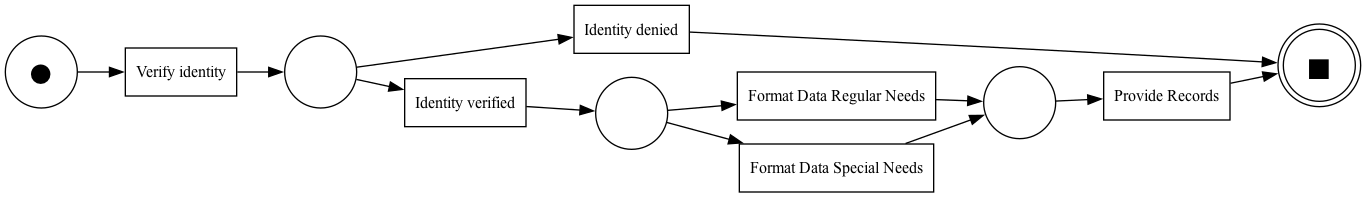

In [2]:
from pm4py.objects.petri_net.importer import importer as pnml_importer
from pm4py.visualization.petri_net import visualizer as pn_visualizer
from IPython.display import Image, display

PNML_PATH = "content/pm.pnml"

net, initial_marking, final_marking = pnml_importer.apply(PNML_PATH)

gviz = pn_visualizer.apply(
    net,
    initial_marking,
    final_marking,
    variant=pn_visualizer.Variants.WO_DECORATION
)

pn_visualizer.save(gviz, "content/petri_net.png")
display(Image("content/petri_net.png"))

In [3]:
import pandas as pd
from pm4py.objects.log.obj import EventLog, Trace, Event
from IPython.display import display, Markdown

summary = pd.read_csv("content/goccva_summary.csv")

# try to detect the trace column
trace_col = None
for c in summary.columns:
    if c.lower() in ["trace", "trace_text", "trace_labels", "variant"]:
        trace_col = c
        break

if trace_col is None:
    raise ValueError("Could not find a trace column in goccva_summary.csv")

print("Using trace column:", trace_col)

def parse_trace_string(trace_text):
    if not isinstance(trace_text, str):
        return []
    txt = trace_text.strip()
    txt = txt.replace("<", "").replace(">", "")
    if "," in txt:
        return [x.strip() for x in txt.split(",") if x.strip()]
    elif ";" in txt:
        return [x.strip() for x in txt.split(";") if x.strip()]
    else:
        return [x.strip() for x in txt.split() if x.strip()]

# build PM4Py log from first 20 traces
log_mixed = EventLog()

for i, row in summary.head(20).iterrows():
    acts = parse_trace_string(row[trace_col])
    tr = Trace()
    tr.attributes["concept:name"] = f"Case_{i+1}"
    for a in acts:
        tr.append(Event({"concept:name": a}))
    log_mixed.append(tr)

display(Markdown("## Event log excerpt"))
for i, tr in enumerate(log_mixed[:10], start=1):
    labels = [e["concept:name"] for e in tr]
    print(f"σ{i} = <" + ", ".join(labels) + ">")

Using trace column: trace


## Event log excerpt

σ1 = <Verify, identity, |, Identity, verified, |, Format, Data, Regular, Needs, |, Provide, Records>
σ2 = <Verify, identity, |, Identity, verified, |, Format, Data, Regular, Needs, |, Provide, Records>
σ3 = <Verify, identity, |, Identity, verified, |, Format, Data, Special, Needs, |, Provide, Records>
σ4 = <Verify, identity, |, Identity, verified, |, Format, Data, Special, Needs, |, Provide, Records>
σ5 = <Verify, identity, |, Identity, verified, |, Format, Data, Special, Needs, |, Provide, Records>
σ6 = <Verify, identity, |, Identity, denied>
σ7 = <Verify, identity, |, Identity, verified, |, Format, Data, Special, Needs, |, Provide, Records>
σ8 = <Manual, accessibility, check, |, Verify, identity, |, Identity, denied>
σ9 = <Verify, identity, |, Identity, verified, |, Format, Data, Regular, Needs, |, Provide, Records>
σ10 = <Verify, identity, |, Identity, verified, |, Format, Data, Regular, Needs, |, Provide, Records>


In [4]:
import pandas as pd
from pm4py.objects.log.obj import EventLog, Trace, Event
from IPython.display import display, Markdown

summary = pd.read_csv("content/goccva_summary.csv")

# try to detect the trace column
trace_col = None
for c in summary.columns:
    if c.lower() in ["trace", "trace_text", "trace_labels", "variant"]:
        trace_col = c
        break

if trace_col is None:
    raise ValueError("Could not find a trace column in goccva_summary.csv")

print("Using trace column:", trace_col)

def parse_trace_string(trace_text):
    if not isinstance(trace_text, str):
        return []
    txt = trace_text.strip()
    txt = txt.replace("<", "").replace(">", "")
    if "," in txt:
        return [x.strip() for x in txt.split(",") if x.strip()]
    elif ";" in txt:
        return [x.strip() for x in txt.split(";") if x.strip()]
    else:
        return [x.strip() for x in txt.split() if x.strip()]

# build PM4Py log from first 20 traces
log_mixed = EventLog()

for i, row in summary.head(20).iterrows():
    acts = parse_trace_string(row[trace_col])
    tr = Trace()
    tr.attributes["concept:name"] = f"Case_{i+1}"
    for a in acts:
        tr.append(Event({"concept:name": a}))
    log_mixed.append(tr)

display(Markdown("## Event log excerpt"))
for i, tr in enumerate(log_mixed[:10], start=1):
    labels = [e["concept:name"] for e in tr]
    print(f"σ{i} = <" + ", ".join(labels) + ">")

Using trace column: trace


## Event log excerpt

σ1 = <Verify, identity, |, Identity, verified, |, Format, Data, Regular, Needs, |, Provide, Records>
σ2 = <Verify, identity, |, Identity, verified, |, Format, Data, Regular, Needs, |, Provide, Records>
σ3 = <Verify, identity, |, Identity, verified, |, Format, Data, Special, Needs, |, Provide, Records>
σ4 = <Verify, identity, |, Identity, verified, |, Format, Data, Special, Needs, |, Provide, Records>
σ5 = <Verify, identity, |, Identity, verified, |, Format, Data, Special, Needs, |, Provide, Records>
σ6 = <Verify, identity, |, Identity, denied>
σ7 = <Verify, identity, |, Identity, verified, |, Format, Data, Special, Needs, |, Provide, Records>
σ8 = <Manual, accessibility, check, |, Verify, identity, |, Identity, denied>
σ9 = <Verify, identity, |, Identity, verified, |, Format, Data, Regular, Needs, |, Provide, Records>
σ10 = <Verify, identity, |, Identity, verified, |, Format, Data, Regular, Needs, |, Provide, Records>


In [5]:
from pm4py.objects.petri_net.importer import importer as pnml_importer

PNML_PATH = "content/fabricated_patient_data_access.pnml"
net, im, fm = pnml_importer.apply(PNML_PATH)

print("Petri net loaded")
print("Places:", len(net.places))
print("Transitions:", len(net.transitions))
print("Arcs:", len(net.arcs))

Petri net loaded
Places: 5
Transitions: 6
Arcs: 12


In [6]:
from pm4py.algo.conformance.alignments.petri_net import algorithm as align_alg

alignments = [align_alg.apply_trace(trace, net, im, fm) for trace in log_mixed]

print("Computed alignments:", len(alignments))

Computed alignments: 18


In [7]:
def normalize_move(x):
    if isinstance(x, tuple):
        return x
    return x

def pretty_label(x):
    if x is None:
        return ">>"
    if isinstance(x, tuple):
        # PM4Py sometimes stores transition info as (name, label)
        if len(x) >= 2:
            return str(x[1]) if x[1] is not None else ">>"
        return str(x)
    return str(x)

def format_alignment_matrix(alignment_pairs):
    normalized = []
    for pair in alignment_pairs:
        if isinstance(pair, (list, tuple)) and len(pair) == 2:
            log_move, model_move = pair
        else:
            log_move, model_move = None, None
        log_str = pretty_label(log_move)
        model_str = pretty_label(model_move)
        normalized.append((log_str, model_str))

    widths = [max(len(log), len(model)) for log, model in normalized]

    model_row = []
    log_row = []

    for (log_move, model_move), width in zip(normalized, widths):
        model_row.append(str(model_move).ljust(width))
        log_row.append(str(log_move).ljust(width))

    separator = " | "
    return separator.join(model_row), separator.join(log_row)

for i, aln in enumerate(alignments[:10], start=1):
    top, bottom = format_alignment_matrix(aln["alignment"])
    print(f"γ{i} =")
    print(top)     # model row
    print(bottom)  # log row
    print("-" * max(len(top), len(bottom)))

γ1 =
>>     | Verify identity | >>       | Identity denied | >> | >>       | >>       | >> | >>     | >>   | >>      | >>    | >> | >>      | >>     
Verify | >>              | identity | >>              | |  | Identity | verified | |  | Format | Data | Regular | Needs | |  | Provide | Records
------------------------------------------------------------------------------------------------------------------------------------------------
γ2 =
>>     | Verify identity | >>       | Identity denied | >> | >>       | >>       | >> | >>     | >>   | >>      | >>    | >> | >>      | >>     
Verify | >>              | identity | >>              | |  | Identity | verified | |  | Format | Data | Regular | Needs | |  | Provide | Records
------------------------------------------------------------------------------------------------------------------------------------------------
γ3 =
>>     | Verify identity | >>       | >> | >>       | >>       | >> | >>     | >>   | >>      | >>    | >> | >>    


## huba_goccva_pipeline.py: reporting logic and role of each step

### Scope
`huba_goccva_pipeline.py` implements a pipeline with five stages:

1. parse the goal model
2. derive graph relations and propagation rules
3. fabricate and simulate a process model
4. compute PM4Py alignments and goal-oriented classifications
5. export tables and detailed alignment data

The report prose is built from the outputs of stage 5.

---

## 1. Parse the goal model

### Code region
- `parse_goal_model`
- dataclasses:
  - `IntentionalElement`
  - `Actor`
  - `IELink`
  - `Dependency`
  - `GoalModel`

### Input
A piStar-style JSON export of the goal model.

### Output
An in-memory `GoalModel` object containing:
- actors
- intentional elements
- internal links
- dependencies

### Role in the evaluation
This step constructs the intentional structure on which the target-based interpretation is defined. It determines:
- which elements are goals, tasks, and qualities
- which links are refinement links
- which links are contribution links
- which cross-actor relations are dependencies

### Report contribution
Every later statement about:
- selected targets
- mapped tasks
- MakeSet, BreakSet, NRSet
- fulfillment status

depends on this parsed structure.

---

## 2. Derive graph relations from the goal model

### Code region
- `parents`
- `children`
- `transitive_parents`
- `transitive_children`
- `refinement_value`
- `contribution_value`
- `dependency_status_transfer`

### Input
The parsed `GoalModel`.

### Output
Structural access functions over the goal model graph.

### Role in the evaluation
This step determines how local task execution is connected to higher-level targets:
- refinement paths connect tasks to goals
- contribution paths connect tasks or goals to qualities
- dependencies connect actor-local elements through dependums

### Report contribution
This step is the basis for any statement about:
- why a task is relevant to a target
- why a task contributes positively or negatively
- how fulfillment propagates beyond the directly executed task

Without these relations, the report would contain only direct task hits and no target-level interpretation.

---

## 3. Define propagation over the marked goal model

### Code region
- `propagate`

### Input
- the `GoalModel`
- a current marking over intentional elements

### Output
An updated marking after repeated application of:
- contribution propagation
- back-propagation
- refinement propagation
- dependency propagation

### Role in the evaluation
This step transforms executed leaf tasks into target-level statuses. A trace does not directly satisfy a goal or a quality merely because one task was executed. The marking changes through the graph structure until no further update applies.

### Report contribution
This step determines the status values that appear in the goal-oriented alignment:
- `satisfied`
- `unknown`
- `pending`
- `denied`

It is therefore the source of all statements about:
- final target satisfaction
- intermediate loss of satisfaction
- stability of satisfaction along the trace

---

## 4. Compute target-relevant task sets

### Code region
- `eventual_contribution_type`
- `compute_target_sets`

### Input
- the `GoalModel`
- one selected target

### Output
For each target:
- `MakeSet`
- `BreakSet`
- `NRSet`

### Role in the evaluation
This step classifies leaf tasks by their relation to a target:
- tasks in `MakeSet` support the target
- tasks in `BreakSet` counter the target
- tasks in `NRSet` are not target-relevant

The construction differs for goals and qualities:
- for qualities, contribution links are inspected directly through transitive parents
- for goals, descendant leaf tasks form `MakeSet`, and conflicts through related qualities form `BreakSet`

### Report contribution
This step is the basis for all statements about:
- which activities support a target
- which activities counter a target
- which activities are outside the target scope

It also determines the move labels used in the goal-oriented alignment.

---

## 5. Propose the activity-to-task mapping

### Code region
- `similarity`
- `propose_mapping`
- `map_move`

### Input
- observed activity labels from the log
- leaf task names from the goal model

### Output
A mapping from activity labels to leaf tasks.

### Role in the evaluation
PM4Py alignments are computed over activity labels from the process model and the log. The goal model is defined over leaf tasks. This step links both vocabularies.

The mapping is proposed by lexical similarity:
- normalized string comparison
- Jaccard overlap
- sequence similarity

### Report contribution
This step is the source of:
- the `goccva_mapping.csv` export
- the connection between aligned moves and intentional elements
- the list of mapped tasks shown inside the goal-oriented alignment

Any sentence about “activity X corresponds to task Y” is grounded in this step.

---

## 6. Label alignment moves with respect to targets

### Code region
- `label_move`

### Input
- one target
- one alignment move
- the activity-to-task mapping
- the target sets

### Output
One label per move and target:
- `M`
- `B`
- `NR`
- `ND`

### Role in the evaluation
This step classifies each move in the alignment with respect to the selected target:
- `M` if the move maps to a target-supporting task
- `B` if the move maps to a target-countering task
- `NR` if it maps to a leaf task outside the target scope
- `ND` if it maps to no task

### Report contribution
This step is the basis for:
- the target-wise move annotation in the goal-oriented alignment
- trace-level interpretation of where support and conflict occur
- any table reproducing the sequence view or the tabular view of the paper

---

## 7. Fabricate the process model

### Code region
- `build_fabricated_petri_net`

### Input
No external process model is loaded. The Petri net is created in code.

### Output
A PM4Py Petri net with:
- `Verify identity`
- `Identity denied`
- `Identity verified`
- `Format Data Regular Needs`
- `Format Data Special Needs`
- `Provide Records`

### Role in the evaluation
This Petri net is the behavioral reference model used for:
- simulation
- alignment computation
- export to PNML

It matches the running example structure:
- verification
- denial or approval
- regular or special formatting
- record provision

### Report contribution
This step determines:
- which traces are behaviorally fitting
- where deviations are introduced by noise
- which alignment moves exist in the detailed results

Any prose comparing traditional and goal-oriented analysis in this script is tied to this fabricated net.

---

## 8. Simulate clean traces

### Code region
- `simulate_clean_log`

### Input
- Petri net
- initial marking
- number of traces

### Output
A PM4Py event log of traces admitted by the Petri net.

### Role in the evaluation
This step produces the behaviorally conforming base log. The traces at this point follow the process model.

### Report contribution
This step provides the reference population from which later noisy traces are derived. It is the source of traces that can receive:
- cost `0`
- optimal alignments without deviations

---

## 9. Inject noise into traces

### Code region
- `clone_trace_with_noise`
- `inject_noise`

### Input
The clean log and the process vocabulary.

### Output
A modified event log in which traces may contain:
- inserted unknown activities
- deleted activities
- swapped adjacent activities
- replaced activities

### Role in the evaluation
This step introduces traces that deviate from the process model while possibly preserving the selected targets.

### Report contribution
This step is the source of:
- non-optimal alignments
- log moves
- model moves
- cases in which behavioral deviation and target fulfillment diverge

The paragraphs on tolerable deviations and critical deviations are derived from traces created here.

---

## 10. Compute PM4Py alignments

### Code region
- `alignments.apply_log`

### Input
- noisy log
- fabricated Petri net
- initial and final marking

### Output
One alignment result per trace, including:
- alignment sequence
- alignment cost
- fitness

### Role in the evaluation
This step produces the traditional conformance view:
- trace-to-model synchronization
- detection of deviations
- distinction between optimal and non-optimal outcomes

### Report contribution
This is the source of:
- `alignment_cost`
- `fitness`
- the traditional comparison baseline

Any sentence comparing control-flow conformance with target-based fulfillment starts from these outputs.

---

## 11. Compute the goal-oriented alignment

### Code region
- `compute_goal_oriented_alignment`

### Input
- one PM4Py alignment
- the goal model
- the activity-to-task mapping
- the selected targets

### Output
For each trace:
- the goal-oriented alignment
- the final marking
- the compliance class

### Internal logic
For each move in the alignment:
1. map the move to leaf tasks
2. mark those tasks as `satisfied`
3. propagate the marking through the goal model
4. compute one `(target, label, status)` triple per target

After processing all moves:
- compute whether all targets are satisfied at the end
- compute whether satisfaction, once reached, is preserved
- classify the trace as:
  - `Strongly compliant`
  - `Weakly compliant`
  - `Non-compliant`

### Report contribution
This step is the source of:
- the detailed goal-oriented alignment in `goccva_details.json`
- the final goal-oriented class in `goccva_summary.csv`
- the target status sequence used in any trace-level explanation

It grounds all report statements about:
- strong fulfillment
- weak fulfillment
- non-fulfillment
- stability of target satisfaction

---

## 12. Select the targets

### Code region
- target selection logic inside `build_outputs`

### Input
The parsed goal model.

### Output
A list of target element ids.

### Selection rule in the script
The script first looks for:
- `data access provided`
- `data easily accesible`

If they are not found, it falls back to:
- one goal
- one quality

### Role in the evaluation
This step fixes the reference point for the goal-oriented assessment.

### Report contribution
The report does not evaluate fulfillment in the abstract. It evaluates fulfillment with respect to the selected targets. All percentages and classifications are target-dependent.

---

## 13. Build the exported summary tables

### Code region
Inside `build_outputs`

### Outputs
- `goccva_summary.csv`
- `goccva_mapping.csv`
- `goccva_targets.csv`
- `goccva_details.json`
- `fabricated_patient_data_access.pnml`

### Role of each export

#### `goccva_summary.csv`
Contains one row per trace with:
- trace id
- trace string
- alignment cost
- fitness
- compliance class

This file is the basis for:
- cross-tabulation between traditional and goal-oriented results
- scenario counts
- percentages used in the report prose

#### `goccva_mapping.csv`
Contains:
- activity labels
- mapped leaf tasks

This file documents the operational link between process activities and the goal model.

#### `goccva_targets.csv`
Contains, per target:
- `MakeSet`
- `BreakSet`
- `NRSet`

This file documents the target-relevance semantics used in the analysis.

#### `goccva_details.json`
Contains, per trace:
- original trace
- PM4Py alignment
- goal-oriented alignment
- final marking
- selected targets

This file is the basis for:
- trace-level inspection
- reproducing examples in the paper
- rendering alignment tables in Colab

#### `fabricated_patient_data_access.pnml`
Contains the behavioral model used by PM4Py.

---

## 14. Relation between goccva.py outputs and the report paragraphs

### Conformance vs Objectives Fulfillment
Derived from:
- `alignment_cost` in `goccva_summary.csv`
- `compliance_class` in `goccva_summary.csv`

### Tolerable Deviations
Derived from traces where:
- alignment cost is non-zero
- compliance class is `Strongly compliant` or `Weakly compliant`

### Apparently Acceptable Cases
Derived from traces where:
- alignment cost is zero
- compliance class is not `Strongly compliant`

### Critical Deviations
Derived from traces where:
- alignment cost is non-zero
- compliance class is `Non-compliant`

### Sequence-level examples
Derived from:
- `goal_oriented_alignment` in `goccva_details.json`

### Activity-to-target explanations
Derived from:
- `goccva_mapping.csv`
- `goccva_targets.csv`

---

## 15. What the script establishes

From the outputs of `huba_goccva_pipeline.py`, the report can establish:

- which traces are behaviorally fitting
- which traces are behaviorally deviant
- which traces satisfy the selected targets at the end
- which traces preserve target satisfaction throughout execution
- which deviations still preserve the selected targets
- which fitting traces still fail the selected targets
- which activities are mapped to target-relevant tasks
- which tasks are in `MakeSet`, `BreakSet`, and `NRSet`
- how target status evolves move by move along each alignment

This is the chain from:
- simulated trace
to
- PM4Py alignment
to
- mapped move
to
- propagated marking
to
- goal-oriented alignment
to
- final compliance class
to
- report-level quantitative comparison
```


In [8]:
with open("huba_goccva_pipeline.py", "r", encoding="utf-8") as f:
    code = f.read()

code = code.replace('"/mnt/data/', '"./')
code = code.replace("'/mnt/data/", "'./")

with open("huba_goccva_pipeline.py", "w", encoding="utf-8") as f:
    f.write(code)

print("Script actualizado para guardar en el directorio actual")

Script actualizado para guardar en el directorio actual


In [9]:
with open("huba_goccva_pipeline.py", "r", encoding="utf-8") as f:
    code = f.read()

code = code.replace("out_dir: str = '/mnt/data'", "out_dir: str = '/content'")
code = code.replace("build_outputs('/mnt/data/goalModel - 2026-04-23T111434.679.txt')",
                    "build_outputs('content/gm.txt')")

with open("huba_goccva_pipeline.py", "w", encoding="utf-8") as f:
    f.write(code)

print("Parche aplicado")

Parche aplicado


In [10]:
## Goal-Oriented Alignments

In [11]:
!python huba_goccva_pipeline.py

aligning log, completed variants :: 100%|███████| 7/7 [00:00<00:00, 2115.44it/s]
{
  "summary_csv": "content/goccva_summary.csv",
  "mapping_csv": "content/goccva_mapping.csv",
  "targets_csv": "content/goccva_targets.csv",
  "details_json": "content/goccva_details.json",
  "pnml": "content/fabricated_patient_data_access.pnml",
  "clean_traces": "[['Verify identity', 'Identity verified', 'Format Data Special Needs', 'Provide Records'], ['Verify identity', 'Identity verified', 'Format Data Special Needs', 'Provide Records'], ['Verify identity', 'Identity verified', 'Format Data Regular Needs', 'Provide Records'], ['Verify identity', 'Identity verified', 'Format Data Regular Needs', 'Provide Records'], ['Verify identity', 'Identity verified', 'Format Data Regular Needs', 'Provide Records']]",
  "noisy_traces": "[['Verify identity', 'Identity verified', 'Format Data Special Needs', 'Provide Records'], ['Verify identity', 'Identity verified', 'Format Data Special Needs', 'Provide Records']

In [12]:
import json
import pandas as pd

with open("content/goccva_details.json", "r", encoding="utf-8") as f:
    details = json.load(f)

print(type(details))
print("length:", len(details))

if len(details) > 0:
    print("first element type:", type(details[0]))
    print("first element:")
    print(details[0])

<class 'list'>
length: 18
first element type: <class 'dict'>
first element:
{'trace_id': 1, 'trace': ['Verify identity', 'Identity verified', 'Format Data Special Needs', 'Provide Records'], 'pm4py_alignment': [['Verify identity', 'Verify identity'], ['Identity verified', 'Identity verified'], ['Format Data Special Needs', 'Format Data Special Needs'], ['Provide Records', 'Provide Records']], 'goal_oriented_alignment': [{'move': ['Verify identity', 'Verify identity'], 'mapped_tasks': ['Verify identity'], 'theta': [{'target': 'Data access provided', 'label': 'NR', 'status': 'unknown'}, {'target': 'data easily accesible', 'label': 'NR', 'status': 'unknown'}]}, {'move': ['Identity verified', 'Identity verified'], 'mapped_tasks': ['Identity verified'], 'theta': [{'target': 'Data access provided', 'label': 'NR', 'status': 'unknown'}, {'target': 'data easily accesible', 'label': 'NR', 'status': 'unknown'}]}, {'move': ['Format Data Special Needs', 'Format Data Special Needs'], 'mapped_tasks':

In [13]:
import pandas as pd

def normalize_goal_oriented_alignments(details):
    rows = []

    if isinstance(details, list):
        iterable = enumerate(details)
    elif isinstance(details, dict):
        iterable = details.items()
    else:
        return pd.DataFrame()

    for trace_id, trace_obj in iterable:
        if not isinstance(trace_obj, dict):
            continue

        goa = (
            trace_obj.get("goal_oriented_alignment")
            or trace_obj.get("goal_alignment")
            or trace_obj.get("alignment")
            or trace_obj.get("steps")
            or []
        )

        compliance = trace_obj.get("compliance_class", trace_obj.get("compliance"))

        for step_idx, step in enumerate(goa, start=1):
            if not isinstance(step, dict):
                continue

            move = step.get("move", step.get("m_i", step.get("alignment_move")))
            theta = step.get("theta", step.get("Theta_i", step.get("targets", [])))

            log_move, model_move = None, None

            if isinstance(move, dict):
                log_move = move.get("log", move.get("a", move.get("left")))
                model_move = move.get("model", move.get("b", move.get("right")))
            elif isinstance(move, (list, tuple)) and len(move) == 2:
                log_move, model_move = move

            if isinstance(theta, dict):
                theta = [
                    {
                        "target": t,
                        "label": vals.get("label"),
                        "status": vals.get("status")
                    }
                    for t, vals in theta.items()
                    if isinstance(vals, dict)
                ]

            for item in theta:
                if isinstance(item, dict):
                    target = item.get("target", item.get("t"))
                    label = item.get("label", item.get("mbnr_label"))
                    status = item.get("status", item.get("marking"))
                elif isinstance(item, (list, tuple)) and len(item) >= 3:
                    target, label, status = item[0], item[1], item[2]
                else:
                    continue

                rows.append({
                    "trace_id": trace_id,
                    "step": step_idx,
                    "log_move": log_move,
                    "model_move": model_move,
                    "target": target,
                    "label": label,
                    "status": status,
                    "compliance_class": compliance
                })

    return pd.DataFrame(rows)

df_goa = normalize_goal_oriented_alignments(details)
df_goa.head(20)

,trace_id,step,log_move,model_move,target,label,status,compliance_class
0,0,1,Verify identity,Verify identity,Data access provided,NR,unknown,None
1,0,1,Verify identity,Verify identity,data easily accesible,NR,unknown,None
2,0,2,Identity verified,Identity verified,Data access provided,NR,unknown,None
3,0,2,Identity verified,Identity verified,data easily accesible,NR,unknown,None
4,0,3,Format Data Special Needs,Format Data Special Needs,Data access provided,M,unknown,None
5,0,3,Format Data Special Needs,Format Data Special Needs,data easily accesible,M,satisfied,None
6,0,4,Provide Records,Provide Records,Data access provided,M,satisfied,None
7,0,4,Provide Records,Provide Records,data easily accesible,NR,satisfied,None
8,1,1,Verify identity,Verify identity,Data access provided,NR,unknown,None
9,1,1,Verify identity,Verify identity,data easily accesible,NR,unknown,None


In [14]:
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

display(df_goa)

,trace_id,step,log_move,model_move,target,label,status,compliance_class
0,0,1,Verify identity,Verify identity,Data access provided,NR,unknown,None
1,0,1,Verify identity,Verify identity,data easily accesible,NR,unknown,None
2,0,2,Identity verified,Identity verified,Data access provided,NR,unknown,None
3,0,2,Identity verified,Identity verified,data easily accesible,NR,unknown,None
4,0,3,Format Data Special Needs,Format Data Special Needs,Data access provided,M,unknown,None
...,...,...,...,...,...,...,...,...
115,17,2,Identity verified,Identity verified,data easily accesible,NR,unknown,None
116,17,3,>>,Format Data Special Needs,Data access provided,M,unknown,None
117,17,3,>>,Format Data Special Needs,data easily accesible,M,satisfied,None
118,17,4,Provide Records,Provide Records,Data access provided,M,satisfied,None


In [15]:
pivot = df_goa.pivot_table(
    index=["trace_id", "step", "log_move", "model_move"],
    columns="target",
    values=["label", "status"],
    aggfunc="first"
).reset_index()

display(pivot)

trace_id step                    log_move                 model_move  \
target                                                                        
0             0    1             Verify identity            Verify identity   
1             0    2           Identity verified          Identity verified   
2             0    3   Format Data Special Needs  Format Data Special Needs   
3             0    4             Provide Records            Provide Records   
4             1    1             Verify identity            Verify identity   
5             1    2           Identity verified          Identity verified   
6             1    3   Format Data Special Needs  Format Data Special Needs   
7             1    4             Provide Records            Provide Records   
8             2    1             Verify identity            Verify identity   
9             2    2           Identity verified          Identity verified   
10            2    3   Format Data Regular Needs  Format Data Regular Needs   
11            2    4             Provide Records            Provide Records   
12            3    1             Verify identity            Verify identity   
13            3    2           Identity verified          Identity verified   
14            3    3   Format Data Regular Needs  Format Data Regular Needs   
15            3    4             Provide Records            Provide Records   
16            4    1             Verify identity            Verify identity   
17            4    2           Identity verified          Identity verified   
18            4    3   Format Data Regular Needs  Format Data Regular Needs   
19            4    4             Provide Records            Provide Records   
20            5    1             Verify identity            Verify identity   
21            5    2             Identity denied            Identity denied   
22            6    1             Verify identity            Verify identity   
23            6    2           Identity verified          Identity verified   
24            6    3   Format Data Regular Needs  Format Data Regular Needs   
25            6    4             Provide Records            Provide Records   
26            7    1  Manual accessibility check                         >>   
27            7    2             Verify identity            Verify identity   
28            7    3             Identity denied            Identity denied   
29            8    1             Verify identity            Verify identity   
30            8    2           Identity verified          Identity verified   
31            8    3   Format Data Special Needs  Format Data Special Needs   
32            8    4             Provide Records            Provide Records   
33            9    1             Verify identity            Verify identity   
34            9    2           Identity verified          Identity verified   
35            9    3   Format Data Special Needs  Format Data Special Needs   
36            9    4             Provide Records            Provide Records   
37           10    1             Verify identity            Verify identity   
38           10    2           Identity verified          Identity verified   
39           10    3  Manual accessibility check                         >>   
40           10    4   Format Data Regular Needs  Format Data Regular Needs   
41           10    5             Provide Records            Provide Records   
42           11    1             Verify identity            Verify identity   
43           11    2             Identity denied            Identity denied   
44           12    1                          >>            Verify identity   
45           12    2             Identity denied            Identity denied   
46           13    1             Verify identity            Verify identity   
47           13    2             Identity denied            Identity denied   
48           14    1             Verify identity         

## Goal-Oriented Compliance Report

## Reporting pipeline: role of each step in the evaluation

### Scope
The report links trace-level alignment results to trace-level target-fulfillment results, then aggregates both views into statements about recurrence, concentration, and classification. The pipeline has four inputs:

- traditional alignment outcome
- goal-oriented classification
- trace variants and activities
- timestamps, when duration-based analysis is included

The report prose is derived from the outputs of the steps below.

---

## 1. Construct a trace-level analysis table

### Input
For each trace:
- alignment cost or fit label
- goal-oriented classification
- trace string or variant identifier

### Output
A table with one row per trace and, at minimum, these fields:
- `trace_id`
- `traditional_class`
- `goal_class`
- `trace_text`
- `variant`

### Function in the report
This table is the base object of the evaluation. It makes it possible to compare, for the same execution, the result of control-flow conformance checking and the result of target-based assessment.

### Claim supported
Any sentence of the form:
- “This trace is fitting but does not satisfy the selected targets.”
- “This trace deviates from the model and still satisfies the selected targets.”

Without this table, those two statements remain disconnected.

---

## 2. Cross-tabulate traditional and goal-oriented outcomes

### Input
The trace-level analysis table.

### Output
A matrix with rows:
- `optimal`
- `non-optimal`

and columns:
- `strongly fulfilled`
- `weakly fulfilled`
- `non-fulfilled`

### Function in the report
This matrix is the basis for the comparison between:
- behavioral fit
- target fulfillment

### Claim supported
Any sentence of the form:
- “Among traces with optimal alignments, x% remain strongly fulfilled, y% are weakly fulfilled, and z% are non-fulfilled.”
- “Among traces with non-optimal alignments, x% are still strongly fulfilled.”

This is the quantitative basis for the distinction between:
- control-flow acceptance
- target satisfaction

---

## 3. Compute row-wise percentages

### Input
The cross-tabulation matrix.

### Output
Percentages for each traditional class:
- distribution of goal-oriented classes among optimal traces
- distribution of goal-oriented classes among non-optimal traces

### Function in the report
These values replace placeholders such as `add %` in the manuscript.

### Claim supported
Any numeric statement in the enterprise scenarios section, including:
- reclassification rates
- fractions of tolerable deviations
- fractions of critical deviations

---

## 4. Partition traces into scenario-specific subsets

### Input
The trace-level analysis table.

### Output
Four subsets:

#### A. Optimal + strongly fulfilled
- behaviorally fitting
- targets fulfilled

#### B. Non-optimal + strongly/weakly fulfilled
- behaviorally deviant
- targets still fulfilled at the end

#### C. Optimal + weakly/non-fulfilled
- behaviorally fitting
- targets not fully satisfied

#### D. Non-optimal + non-fulfilled
- behaviorally deviant
- targets not satisfied at the end

### Function in the report
These subsets correspond to the scenario structure of the section.

### Claim supported
The paragraphs on:
- conformance vs objectives fulfillment
- tolerable deviations
- apparently acceptable cases
- critical deviations

---

## 5. Count trace variants inside each subset

### Input
Each scenario-specific subset.

### Output
A frequency table of variants:
- variant identifier
- number of traces
- percentage within the subset

### Function in the report
This step shows whether the classified traces are dispersed or concentrated in repeated execution patterns.

### Claim supported
Any sentence of the form:
- “x% of these traces are concentrated in y recurrent variants.”
- “These cases occur in a small number of high-frequency variants.”

This is the basis for statements about recurrence at the variant level.

---

## 6. Count activities inside each subset

### Input
Each scenario-specific subset.

### Output
A frequency table of activities:
- activity name
- number of traces containing the activity
- percentage within the subset

### Function in the report
This step identifies which activities recur inside a given scenario.

### Claim supported
Any sentence of the form:
- “These traces are associated with activity A.”
- “The unsupported targets recur in traces containing activity B.”

This is the basis for statements about recurrence at the activity level.

---

## 7. Count activity pairs inside each subset

### Input
Each scenario-specific subset.

### Output
A frequency table of co-occurring activity pairs:
- `activity_1`
- `activity_2`
- number of traces containing the pair
- percentage within the subset

### Function in the report
This step captures repeated combinations of actions, rather than isolated actions.

### Claim supported
Any sentence of the form:
- “A recurrent pair is activity A together with activity B.”
- “These cases concentrate in variants containing A and B.”

This is the basis for statements about repeated combinations.

---

## 8. Build scenario-level summary tables

### Input
The percentages from the comparison matrix and the scenario-specific frequencies.

### Output
A compact table with, for each scenario:
- total number of traces
- percentage by goal-oriented class
- top variants
- top activities
- top activity pairs

### Function in the report
This table is the intermediate object between computation and prose.

### Claim supported
The full set of quantitative statements in the scenario section.

---

## 9. Generate scenario-level report text

### Input
The summary tables and the top-frequency patterns.

### Output
Draft prose for each scenario paragraph.

### Function in the report
This step maps counts and percentages to paragraph-level statements.

### Claim supported
Sentences such as:
- “Among the traces with optimal alignments, x% remain strongly fulfilled…”
- “Among the traces with non-optimal alignments, x% are still strongly fulfilled…”
- “x% of these traces belong to variants containing activity A and activity B…”

The prose is therefore tied to the computed aggregates.

---

## 10. Add time-based analysis when timestamps are available

### Input
Per-event timestamps or waiting times.

### Output
Duration tables by:
- activity
- transition
- stage
- scenario-specific subset

### Function in the report
This step connects delay patterns to goal-oriented classes.

### Claim supported
Any sentence of the form:
- “Among traces passing through activity A, x% are non-fulfilled.”
- “Delayed approval stages recur in traces classified as weakly fulfilled or non-fulfilled.”

Without timestamps, the report can still cover:
- reclassification
- recurrence by variants
- recurrence by activities
- recurrence by activity pairs

It cannot support duration-based claims.

---

## 11. Relation between pipeline outputs and the manuscript paragraphs

### Conformance vs Objectives Fulfillment
Derived from:
- cross-tabulation
- row-wise percentages

### Tolerable Deviations
Derived from:
- subset B
- variant frequencies in B
- activity frequencies in B
- pair frequencies in B

### Apparently Acceptable Cases
Derived from:
- subset C
- variant frequencies in C
- activity frequencies in C
- pair frequencies in C

### Critical Deviations
Derived from:
- subset D
- variant frequencies in D
- activity frequencies in D
- pair frequencies in D

### Bottleneck Interpretation
Derived from:
- timestamps
- duration aggregates
- cross-reference with goal-oriented classes

### Stakeholder-Sensitive Interpretation
Derived from:
- repeating the same pipeline for different target sets
- comparing how classifications change when the selected targets change

---

## 12. What the report establishes

The report establishes, from the computed outputs:

- where traditional conformance and target fulfillment coincide
- where they diverge
- how often each divergence occurs
- in which variants those divergences occur
- which activities and activity pairs recur in those divergences
- which delayed stages co-occur with those divergences, when timestamps are present

This is the chain from:
- trace-level alignment output
to
- scenario-level quantitative statements
to
- paragraph-level interpretation

In [16]:
import json
import pandas as pd
from collections import Counter

with open("content/goccva_details.json", "r", encoding="utf-8") as f:
    details = json.load(f)

summary = pd.read_csv("content/goccva_summary.csv")
mapping = pd.read_csv("content/goccva_mapping.csv")
targets = pd.read_csv("content/goccva_targets.csv")

print("details type:", type(details))
print("summary shape:", summary.shape)
display(summary.head())

details type: <class 'list'>
summary shape: (18, 5)


,trace_id,trace,alignment_cost,fitness,compliance_class
0,1,Verify identity | Identity verified | Format Data Special Needs | Provide Records,0,1.0,Strongly compliant
1,2,Verify identity | Identity verified | Format Data Special Needs | Provide Records,0,1.0,Strongly compliant
2,3,Verify identity | Identity verified | Format Data Regular Needs | Provide Records,0,1.0,Non-compliant
3,4,Verify identity | Identity verified | Format Data Regular Needs | Provide Records,0,1.0,Non-compliant
4,5,Verify identity | Identity verified | Format Data Regular Needs | Provide Records,0,1.0,Non-compliant


In [17]:
print(summary.columns.tolist())

['trace_id', 'trace', 'alignment_cost', 'fitness', 'compliance_class']


In [18]:
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

trace_col = pick_col(summary, ["trace_id", "case_id", "id"])
trace_str_col = pick_col(summary, ["trace", "trace_labels", "variant", "trace_string"])
cost_col = pick_col(summary, ["alignment_cost", "cost"])
goal_class_col = pick_col(summary, ["compliance_class", "goal_compliance", "classification"])

fit_col = pick_col(summary, [
    "is_optimal_fit", "optimal_fit", "is_fitting", "fitting", "traditional_fit"
])

summary_norm = summary.copy()

if fit_col is None and cost_col is not None:
    summary_norm["traditional_class"] = summary_norm[cost_col].apply(
        lambda x: "optimal" if float(x) == 0 else "non-optimal"
    )
else:
    summary_norm["traditional_class"] = summary_norm[fit_col].apply(
        lambda x: "optimal" if str(x).lower() in ["true", "1", "yes", "optimal", "fit", "fitting"] else "non-optimal"
    )

summary_norm["goal_class"] = summary_norm[goal_class_col].replace({
    "Strongly compliant": "strongly fulfilled",
    "Weakly compliant": "weakly fulfilled",
    "Non-compliant": "non-fulfilled",
    "strongly compliant": "strongly fulfilled",
    "weakly compliant": "weakly fulfilled",
    "non-compliant": "non-fulfilled",
})

if trace_str_col is not None:
    summary_norm["trace_text"] = summary_norm[trace_str_col].astype(str)
else:
    summary_norm["trace_text"] = ""

summary_norm["variant"] = summary_norm["trace_text"]

display(summary_norm[["traditional_class", "goal_class", "trace_text"]].head())

,traditional_class,goal_class,trace_text
0,optimal,strongly fulfilled,Verify identity | Identity verified | Format Data Special Needs | Provide Records
1,optimal,strongly fulfilled,Verify identity | Identity verified | Format Data Special Needs | Provide Records
2,optimal,non-fulfilled,Verify identity | Identity verified | Format Data Regular Needs | Provide Records
3,optimal,non-fulfilled,Verify identity | Identity verified | Format Data Regular Needs | Provide Records
4,optimal,non-fulfilled,Verify identity | Identity verified | Format Data Regular Needs | Provide Records


In [19]:
comparison = pd.crosstab(
    summary_norm["traditional_class"],
    summary_norm["goal_class"],
    margins=True
)

comparison_pct = pd.crosstab(
    summary_norm["traditional_class"],
    summary_norm["goal_class"],
    normalize="index"
).round(4) * 100

display(comparison)
display(comparison_pct)

goal_class,non-fulfilled,strongly fulfilled,All
traditional_class,,,
non-optimal,3,1,4
optimal,10,4,14
All,13,5,18


goal_class,non-fulfilled,strongly fulfilled
traditional_class,,
non-optimal,75.00,25.00
optimal,71.43,28.57


In [20]:
def pct(part, total):
    return round((100 * part / total), 2) if total else 0.0

n_total = len(summary_norm)

optimal_df = summary_norm[summary_norm["traditional_class"] == "optimal"]
nonoptimal_df = summary_norm[summary_norm["traditional_class"] == "non-optimal"]

n_opt = len(optimal_df)
n_nonopt = len(nonoptimal_df)

opt_strong = len(optimal_df[optimal_df["goal_class"] == "strongly fulfilled"])
opt_weak = len(optimal_df[optimal_df["goal_class"] == "weakly fulfilled"])
opt_non = len(optimal_df[optimal_df["goal_class"] == "non-fulfilled"])

nonopt_strong = len(nonoptimal_df[nonoptimal_df["goal_class"] == "strongly fulfilled"])
nonopt_weak = len(nonoptimal_df[nonoptimal_df["goal_class"] == "weakly fulfilled"])
nonopt_non = len(nonoptimal_df[nonoptimal_df["goal_class"] == "non-fulfilled"])

metrics = {
    "optimal_total": n_opt,
    "nonoptimal_total": n_nonopt,
    "optimal_strong_pct": pct(opt_strong, n_opt),
    "optimal_weak_pct": pct(opt_weak, n_opt),
    "optimal_non_pct": pct(opt_non, n_opt),
    "nonoptimal_strong_pct": pct(nonopt_strong, n_nonopt),
    "nonoptimal_weak_pct": pct(nonopt_weak, n_nonopt),
    "nonoptimal_non_pct": pct(nonopt_non, n_nonopt),
}

metrics

{'optimal_total': 14,
 'nonoptimal_total': 4,
 'optimal_strong_pct': 28.57,
 'optimal_weak_pct': 0.0,
 'optimal_non_pct': 71.43,
 'nonoptimal_strong_pct': 25.0,
 'nonoptimal_weak_pct': 0.0,
 'nonoptimal_non_pct': 75.0}

In [21]:
case_A = summary_norm[
    (summary_norm["traditional_class"] == "optimal") &
    (summary_norm["goal_class"] == "strongly fulfilled")
].copy()

case_B = summary_norm[
    (summary_norm["traditional_class"] == "non-optimal") &
    (summary_norm["goal_class"].isin(["strongly fulfilled", "weakly fulfilled"]))
].copy()

case_C = summary_norm[
    (summary_norm["traditional_class"] == "optimal") &
    (summary_norm["goal_class"].isin(["weakly fulfilled", "non-fulfilled"]))
].copy()

case_D = summary_norm[
    (summary_norm["traditional_class"] == "non-optimal") &
    (summary_norm["goal_class"] == "non-fulfilled")
].copy()

print("A: optimal + strongly fulfilled =", len(case_A))
print("B: non-optimal + objectives still satisfied =", len(case_B))
print("C: optimal + objectives not fully satisfied =", len(case_C))
print("D: non-optimal + non-fulfilled =", len(case_D))

A: optimal + strongly fulfilled = 4
B: non-optimal + objectives still satisfied = 1
C: optimal + objectives not fully satisfied = 10
D: non-optimal + non-fulfilled = 3


In [22]:
def variant_frequency(df):
    out = (
        df.groupby("variant")
          .size()
          .reset_index(name="frequency")
          .sort_values("frequency", ascending=False)
    )
    out["pct_within_case"] = (100 * out["frequency"] / len(df)).round(2) if len(df) else 0.0
    return out

variants_B = variant_frequency(case_B)
variants_C = variant_frequency(case_C)
variants_D = variant_frequency(case_D)

display(variants_B.head(10))
display(variants_C.head(10))
display(variants_D.head(10))

,variant,frequency,pct_within_case
0,Verify identity | Identity verified | Provide Records,1,100.0


,variant,frequency,pct_within_case
0,Verify identity | Identity denied,5,50.0
1,Verify identity | Identity verified | Format Data Regular Needs | Provide Records,5,50.0


,variant,frequency,pct_within_case
0,Identity denied,1,33.33
1,Manual accessibility check | Verify identity | Identity denied,1,33.33
2,Verify identity | Identity verified | Manual accessibility check | Format Data Regular Needs | Provide Records,1,33.33


In [23]:
def split_activities(trace_text):
    if not isinstance(trace_text, str):
        return []
    # adjust this if your trace strings use another separator
    txt = trace_text.strip()
    txt = txt.replace("<", "").replace(">", "")
    if "," in txt:
        return [x.strip() for x in txt.split(",") if x.strip()]
    if ";" in txt:
        return [x.strip() for x in txt.split(";") if x.strip()]
    return [x.strip() for x in txt.split() if x.strip()]

def activity_stats(df):
    counter = Counter()
    for t in df["trace_text"].tolist():
        acts = split_activities(t)
        counter.update(set(acts))   # set(...) counts per trace, not repeated occurrences inside one trace
    rows = [{"activity": a, "trace_count": c, "pct_within_case": round(100*c/len(df), 2)} for a, c in counter.items()]
    return pd.DataFrame(rows).sort_values(["trace_count", "activity"], ascending=[False, True])

acts_B = activity_stats(case_B)
acts_C = activity_stats(case_C)
acts_D = activity_stats(case_D)

display(acts_B.head(10))
display(acts_C.head(10))
display(acts_D.head(10))

,activity,trace_count,pct_within_case
1,Identity,1,100.0
4,Provide,1,100.0
3,Records,1,100.0
0,Verify,1,100.0
5,identity,1,100.0
2,verified,1,100.0
6,|,1,100.0


,activity,trace_count,pct_within_case
2,Identity,10,100.0
1,Verify,10,100.0
7,identity,10,100.0
8,|,10,100.0
10,Data,5,50.0
9,Format,5,50.0
0,Needs,5,50.0
6,Provide,5,50.0
4,Records,5,50.0
5,Regular,5,50.0


,activity,trace_count,pct_within_case
1,Identity,3,100.00
3,Manual,2,66.67
0,Verify,2,66.67
2,accessibility,2,66.67
4,check,2,66.67
7,denied,2,66.67
6,identity,2,66.67
5,|,2,66.67
14,Data,1,33.33
13,Format,1,33.33


In [24]:
from itertools import combinations

def pair_stats(df):
    counter = Counter()
    for t in df["trace_text"].tolist():
        acts = sorted(set(split_activities(t)))
        for pair in combinations(acts, 2):
            counter[pair] += 1
    rows = [{
        "activity_1": p[0],
        "activity_2": p[1],
        "trace_count": c,
        "pct_within_case": round(100*c/len(df), 2)
    } for p, c in counter.items()]
    if not rows:
        return pd.DataFrame(columns=["activity_1", "activity_2", "trace_count", "pct_within_case"])
    return pd.DataFrame(rows).sort_values("trace_count", ascending=False)

pairs_B = pair_stats(case_B)
pairs_C = pair_stats(case_C)
pairs_D = pair_stats(case_D)

display(pairs_B.head(10))
display(pairs_C.head(10))
display(pairs_D.head(10))

,activity_1,activity_2,trace_count,pct_within_case
0,Identity,Provide,1,100.0
11,Records,Verify,1,100.0
19,identity,|,1,100.0
18,identity,verified,1,100.0
17,Verify,|,1,100.0
16,Verify,verified,1,100.0
15,Verify,identity,1,100.0
14,Records,|,1,100.0
13,Records,verified,1,100.0
12,Records,identity,1,100.0


,activity_1,activity_2,trace_count,pct_within_case
51,Verify,|,10,100.0
49,Verify,identity,10,100.0
26,Identity,|,10,100.0
53,identity,|,10,100.0
23,Identity,Verify,10,100.0
24,Identity,identity,10,100.0
40,Records,Regular,5,50.0
39,Provide,|,5,50.0
38,Provide,verified,5,50.0
37,Provide,identity,5,50.0


,activity_1,activity_2,trace_count,pct_within_case
0,Identity,Manual,2,66.67
12,Manual,|,2,66.67
27,identity,|,2,66.67
24,check,|,2,66.67
23,check,identity,2,66.67
21,accessibility,|,2,66.67
20,accessibility,identity,2,66.67
18,accessibility,check,2,66.67
17,Verify,|,2,66.67
16,Verify,identity,2,66.67


In [25]:
report_table = pd.DataFrame([
    {
        "scenario": "Conformance vs objectives fulfillment",
        "population": "optimal alignments",
        "strongly_fulfilled_pct": metrics["optimal_strong_pct"],
        "weakly_fulfilled_pct": metrics["optimal_weak_pct"],
        "non_fulfilled_pct": metrics["optimal_non_pct"],
        "n": n_opt
    },
    {
        "scenario": "Tolerable deviations",
        "population": "non-optimal alignments",
        "strongly_fulfilled_pct": metrics["nonoptimal_strong_pct"],
        "weakly_fulfilled_pct": metrics["nonoptimal_weak_pct"],
        "non_fulfilled_pct": metrics["nonoptimal_non_pct"],
        "n": n_nonopt
    }
])

display(report_table)

,scenario,population,strongly_fulfilled_pct,weakly_fulfilled_pct,non_fulfilled_pct,n
0,Conformance vs objectives fulfillment,optimal alignments,28.57,0.0,71.43,14
1,Tolerable deviations,non-optimal alignments,25.00,0.0,75.00,4


In [26]:
def top_variant_sentence(df_variants, label):
    if len(df_variants) == 0:
        return f"No recurrent variants were observed for {label}."
    top = df_variants.iloc[0]
    return (
        f"The most frequent variant in this category appears {int(top['frequency'])} times "
        f"({top['pct_within_case']}\\%) within the category."
    )

def top_pair_sentence(df_pairs, label):
    if len(df_pairs) == 0:
        return f"No dominant activity pair was observed for {label}."
    top = df_pairs.iloc[0]
    return (
        f"A recurrent activity pair is \\textit{{{top['activity_1']}}} and "
        f"\\textit{{{top['activity_2']}}}, appearing in {int(top['trace_count'])} traces "
        f"({top['pct_within_case']}\\%) of this category."
    )

report_text = f"""
\\paragraph{{Conformance vs Objectives Fulfillment}}
Among the traces with optimal alignments, {metrics['optimal_strong_pct']}\\% remain strongly fulfilled,
{metrics['optimal_weak_pct']}\\% are reclassified as weakly fulfilled, and
{metrics['optimal_non_pct']}\\% are reclassified as non-fulfilled.
This indicates that traditional alignment-based conformance may under-approximate problematic cases,
since behaviorally fitting traces may still fail to satisfy selected targets.

\\paragraph{{Tolerable Deviations: Non-compliant with the process model, objectives satisfied}}
Among the traces with non-optimal alignments, {metrics['nonoptimal_strong_pct']}\\% are still classified as strongly fulfilled and
{metrics['nonoptimal_weak_pct']}\\% as weakly fulfilled.
This shows that traditional conformance checking may over-approximate problematic behavior, since some deviations do not compromise the selected concerns.
{top_variant_sentence(variants_B, 'tolerable deviations')}
{top_pair_sentence(pairs_B, 'tolerable deviations')}

\\paragraph{{Apparently Acceptable Cases: Compliant with the process model, objectives not satisfied}}
Among the traces with optimal alignments, {metrics['optimal_strong_pct']}\\% remain strongly fulfilled,
{metrics['optimal_weak_pct']}\\% are reclassified as weakly fulfilled, and
{metrics['optimal_non_pct']}\\% are reclassified as non-fulfilled.
These results reveal traces that are acceptable from the control-flow perspective but unsatisfactory with respect to the selected targets.
{top_variant_sentence(variants_C, 'apparently acceptable cases')}
{top_pair_sentence(pairs_C, 'apparently acceptable cases')}

\\paragraph{{Critical Deviations: Non-compliant with the process model, objectives not satisfied}}
Among the traces with non-optimal alignments, {metrics['nonoptimal_non_pct']}\\% are classified as non-fulfilled.
These traces are problematic from both perspectives because they combine behavioral deviation with failure to satisfy the selected targets.
{top_variant_sentence(variants_D, 'critical deviations')}
{top_pair_sentence(pairs_D, 'critical deviations')}
"""

print(report_text)


\paragraph{Conformance vs Objectives Fulfillment}
Among the traces with optimal alignments, 28.57\% remain strongly fulfilled,
0.0\% are reclassified as weakly fulfilled, and
71.43\% are reclassified as non-fulfilled.
This indicates that traditional alignment-based conformance may under-approximate problematic cases,
since behaviorally fitting traces may still fail to satisfy selected targets.

\paragraph{Tolerable Deviations: Non-compliant with the process model, objectives satisfied}
Among the traces with non-optimal alignments, 25.0\% are still classified as strongly fulfilled and
0.0\% as weakly fulfilled.
This shows that traditional conformance checking may over-approximate problematic behavior, since some deviations do not compromise the selected concerns.
The most frequent variant in this category appears 1 times (100.0\%) within the category.
A recurrent activity pair is \textit{Identity} and \textit{Provide}, appearing in 1 traces (100.0\%) of this category.

\paragraph{Appar

In [27]:
with open("content/goal_oriented_compliance_report.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

print("Saved: content/goal_oriented_compliance_report.txt")

Saved: content/goal_oriented_compliance_report.txt


In [28]:
print("Traditional vs Goal-Oriented Classification")
display(comparison)
display(comparison_pct)

print("\nTolerable deviations")
display(variants_B.head(10))
display(acts_B.head(10))
display(pairs_B.head(10))

print("\nApparently acceptable cases")
display(variants_C.head(10))
display(acts_C.head(10))
display(pairs_C.head(10))

print("\nCritical deviations")
display(variants_D.head(10))
display(acts_D.head(10))
display(pairs_D.head(10))

Traditional vs Goal-Oriented Classification


goal_class,non-fulfilled,strongly fulfilled,All
traditional_class,,,
non-optimal,3,1,4
optimal,10,4,14
All,13,5,18


goal_class,non-fulfilled,strongly fulfilled
traditional_class,,
non-optimal,75.00,25.00
optimal,71.43,28.57



Tolerable deviations


,variant,frequency,pct_within_case
0,Verify identity | Identity verified | Provide Records,1,100.0


...

,activity_1,activity_2,trace_count,pct_within_case
51,Verify,|,10,100.0
49,Verify,identity,10,100.0
26,Identity,|,10,100.0
53,identity,|,10,100.0
23,Identity,Verify,10,100.0
24,Identity,identity,10,100.0
40,Records,Regular,5,50.0
39,Provide,|,5,50.0
38,Provide,verified,5,50.0
37,Provide,identity,5,50.0



Critical deviations


,variant,frequency,pct_within_case
0,Identity denied,1,33.33
1,Manual accessibility check | Verify identity | Identity denied,1,33.33
2,Verify identity | Identity verified | Manual accessibility check | Format Data Regular Needs | Provide Records,1,33.33


,activity,trace_count,pct_within_case
1,Identity,3,100.00
3,Manual,2,66.67
0,Verify,2,66.67
2,accessibility,2,66.67
4,check,2,66.67
7,denied,2,66.67
6,identity,2,66.67
5,|,2,66.67
14,Data,1,33.33
13,Format,1,33.33


,activity_1,activity_2,trace_count,pct_within_case
0,Identity,Manual,2,66.67
12,Manual,|,2,66.67
27,identity,|,2,66.67
24,check,|,2,66.67
23,check,identity,2,66.67
21,accessibility,|,2,66.67
20,accessibility,identity,2,66.67
18,accessibility,check,2,66.67
17,Verify,|,2,66.67
16,Verify,identity,2,66.67
